# ISRO Chandrayaan-2 Demo

## Import the required libraries

In [1]:
import pds.peppi as peppi
from datetime import datetime
from pprint import pprint

## Connect to the API

In [2]:
client = peppi.PDSRegistryClient()

## Query for XSM Data Products

The guaranteed way to match this, is using internal reference LIDs.

In [5]:
products = peppi.Products(client)

my_products = products.has_instrument("urn:isro:isda:context:instrument:xsm.ch2orbiter")

# I only want the data from the last few days in April
start_date = datetime.fromisoformat("2026-04-25")
end_date = datetime.fromisoformat("2026-05-01")
my_products = my_products.after(start_date).before(end_date)

# Unfortunately, this does not work without internal references to the instrument

## Query for All XSM Data Products by Instrument Name

In [12]:
products = peppi.Products(client)
my_products = products.filter('pds:Observing_System_Component.pds:name eq "Solar X-ray Monitor"')

# Normally you could call my_products.count() here, but it isn't working at the moment
count=0
for _, product in enumerate(my_products):
    count = count+1
print(count)

57


## Query for Calibrated XSM Data Products Only

In [13]:
my_products.has_processing_level("Calibrated")

# Rudimentary way to get count since count() is current broken :-) 
count=0
for _, product in enumerate(my_products):
    count = count+1
print(count)


29


## Translate to a pandas dataframe to see the time ranges available


In [14]:
my_products = my_products.fields(["pds:Time_Coordinates.pds:start_date_time", "pds:Time_Coordinates.pds:stop_date_time"])

import pandas as pd
df = my_products.as_dataframe()
df

,pds:Time_Coordinates.pds:start_date_time,pds:Time_Coordinates.pds:stop_date_time,ops:Harvest_Info.ops:harvest_date_time
urn:isro:isda:ch2_cho.xsm::1.0,2026-04-22T00:00:00.708Z,2026-05-02T23:59:59.613Z,2026-05-19T16:43:51.819096Z
urn:isro:isda:ch2_cho.xsm:data_calibrated::1.0,2026-04-22T00:00:00.708Z,2026-05-02T23:59:59.613Z,2026-05-19T16:50:44.046643Z
urn:isro:isda:ch2_cho.xsm:data_calibrated:ch2_xsm_20260427_level2_gti::1.0,2026-04-27T00:00:00.649Z,2026-04-27T23:59:59.336Z,2026-05-19T16:50:46.042092Z
urn:isro:isda:ch2_cho.xsm:data_calibrated:ch2_xsm_20260427_level2_lc::1.0,2026-04-27T00:00:00.649Z,2026-04-27T23:59:59.336Z,2026-05-19T16:50:46.056771Z
urn:isro:isda:ch2_cho.xsm:data_calibrated:ch2_xsm_20260427_level2_pha::1.0,2026-04-27T00:00:00.649Z,2026-04-27T23:59:59.336Z,2026-05-19T16:50:46.078193Z
urn:isro:isda:ch2_cho.xsm:data_calibrated:ch2_xsm_20260429_level2_pha::1.0,2026-04-29T00:00:00.007Z,2026-04-29T23:59:59.843Z,2026-05-19T16:50:46.431136Z
urn:isro:isda:ch2_cho.xsm:data_calibrated:ch2_xsm_20260429_level2_lc::1.0,2026-04-29T00:00:00.007Z,2026-04-29T23:59:59.843Z,2026-05-19T16:50:46.451965Z
urn:isro:isda:ch2_cho.xsm:data_calibrated:ch2_xsm_20260429_level2_gti::1.0,2026-04-29T00:00:00.007Z,2026-04-29T23:59:59.843Z,2026-05-19T16:50:46.459319Z
urn:isro:isda:ch2_cho.xsm:data_calibrated:ch2_xsm_20260428_level2_lc::1.0,2026-04-28T00:00:00.336Z,2026-04-28T23:59:59.007Z,2026-05-19T16:50:46.799332Z
urn:isro:isda:ch2_cho.xsm:data_calibrated:ch2_xsm_20260428_level2_pha::1.0,2026-04-28T00:00:00.336Z,2026-04-28T23:59:59.007Z,2026-05-19T16:50:46.806491Z


## Download the products we want

Or all of them

In [ ]:
for _, product in enumerate(products):

    # download label
    remote_label_path = product.properties['ops:Label_File_Info.ops:file_ref'][0]
    local_label_path = os.path.basename(remote_label_path)
    urlretrieve(remote_label_path, local_label_path)
 
    # download product
    remote_data_path = product.properties['ops:Data_File_Info.ops:file_ref'][0]
    local_data_path = os.path.basename(remote_data_path)
    urlretrieve(remote_data_path, local_data_path)

## Plot the Pulse Height Amplitude (PHA) data from 2026-04-29

Available data blocks inside dataset: ['header_Primary', 'header_Spectrum', 'data_Spectrum', 'label']

First few columns discovered by PDR:
['SPEC_NUM', 'CHANNEL_0', 'CHANNEL_1', 'CHANNEL_2', 'CHANNEL_3', 'CHANNEL_4', 'CHANNEL_5', 'CHANNEL_6', 'CHANNEL_7', 'CHANNEL_8']

Successfully loaded 1039 rows.
Reshaped COUNTS array into matrix size: (1039, 512)


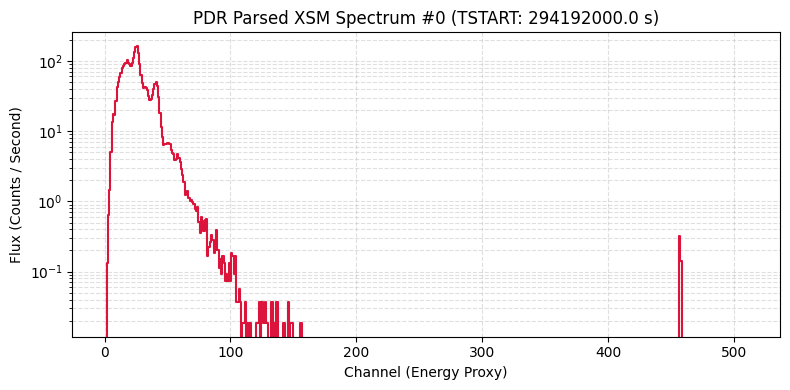

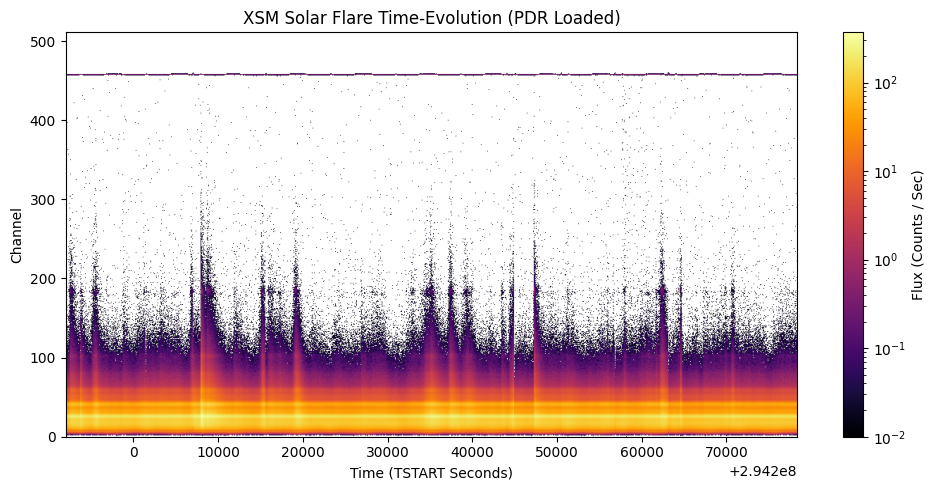

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pdr

# 1. Load the PDS4 dataset using pdr
xml_file_path = "/Users/jpadams/test/isro_demo/data/ch2/xsm/data/2026/04/29/calibrated/ch2_xsm_20260429_v1_level2_pha.xml"
dataset = pdr.read(xml_file_path)

# --- UNDERSTANDING THE PDR STRUCTURE ---
# pdr parses files and populates a `.keys()` registry. 
# It typically maps your PDS4 Table_Binary structure into a key named 'data'.
print("Available data blocks inside dataset:", dataset.keys())

# Grab the data_Spectrum table (usually a customized Pandas DataFrame or NumPy structured array)
df = dataset["data_Spectrum"]

# If pdr returns a DataFrame, we can easily list or search the columns
print("\nFirst few columns discovered by PDR:")
print(list(df.columns)[:10] if hasattr(df, "columns") else "Structured array found")

# --- BULLETPROOF FIELD EXTRACTION FROM THE METADATA OBJECT ---
# Because PDR retains multi-indexed group fields, we can locate 
# the underlying exact column names by checking for substrings.
def find_col(dataframe, keyword):
    for col in dataframe.columns:
        if keyword.lower() in col.lower():
            return col
    raise KeyError(f"Could not find field containing keyword: {keyword}")

# Find the exact structural names
spec_num_col = find_col(df, "SPEC_NUM")
exposure_col = find_col(df, "EXPOSURE")
tstart_col = find_col(df, "TSTART")

# Extract vector arrays as NumPy floats/ints
spec_nums = df[spec_num_col].to_numpy()
exposures = df[exposure_col].to_numpy()
tstarts = df[tstart_col].to_numpy()

# PDR flattens nested group fields like COUNTS into ordered sequences:
# (e.g., COUNTS_0, COUNTS_1 ... COUNTS_511)
count_cols = [c for c in df.columns if "counts" in c.lower()]
counts_matrix = df[count_cols].to_numpy() # Converts 512 columns into a 2D matrix

# Generate a sequential channel mapping array (0 to 511) for our X-axis
channels = np.arange(counts_matrix.shape[1])

print(f"\nSuccessfully loaded {len(spec_nums)} rows.")
print(f"Reshaped COUNTS array into matrix size: {counts_matrix.shape}")


# ==========================================
# PLOT 1: Individual Spectrum (Single Row)
# ==========================================
row_idx = 0
# Avoid divide-by-zero errors if exposure is missing
safe_exp = exposures[row_idx] if exposures[row_idx] > 0 else 1.0
flux_single = counts_matrix[row_idx] / safe_exp

plt.figure(figsize=(8, 4))
plt.plot(channels, flux_single, color="crimson", drawstyle="steps-mid")
plt.title(f"PDR Parsed XSM Spectrum #{spec_nums[row_idx]} (TSTART: {tstarts[row_idx]:.1f} s)")
plt.xlabel("Channel (Energy Proxy)")
plt.ylabel("Flux (Counts / Second)")
plt.yscale("log")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.tight_layout()
plt.show()


# ==========================================
# PLOT 2: Dynamic Spectrogram Heatmap (FIXED)
# ==========================================
if len(spec_nums) > 1:
    # Scale entire matrix safely by row exposure
    safe_exposures = np.where(exposures <= 0, 1.0, exposures)
    flux_matrix = counts_matrix / safe_exposures[:, np.newaxis]

    plt.figure(figsize=(10, 5))
    
    # --- THE FIX ---
    # Convert sequence boundaries into single scalar definitions: [xmin, xmax, ymin, ymax]
    extent_bounds = [tstarts[0], tstarts[-1], channels[0], channels[-1]]
    
    plt.imshow(
        flux_matrix.T,
        aspect="auto",
        origin="lower",
        extent=extent_bounds,
        cmap="inferno",
        norm=plt.cm.colors.LogNorm(vmin=1e-2, vmax=np.nanmax(flux_matrix) + 1),
    )
    
    plt.colorbar(label="Flux (Counts / Sec)")
    plt.title("XSM Solar Flare Time-Evolution (PDR Loaded)")
    plt.xlabel("Time (TSTART Seconds)")
    plt.ylabel("Channel")
    plt.tight_layout()
    plt.show()

